# 20 · H1 Revisited — Tuned Multi-Model Bake-off + Modern Metric Suite

**H1.** *Does ASR-native uncertainty add predictive signal **beyond** intent-native
uncertainty?* We answer it the way a reviewer would want: not with one model, but
with **six hyperparameter-tuned classifiers** over three feature families, scored
on the **frozen 30% held-out test set** with the full modern reliability metric
suite, and settled with a **paired bootstrap** CI on ΔROC-AUC.

- Families: **A** = ASR-native (9) · **B** = intent-native (3) · **C** = combined (12).
- Models: LogReg, RandomForest, HistGB, XGBoost, LightGBM, MLP — each tuned with
  `RandomizedSearchCV` on **train only** (inner 4-fold CV). The frozen test set is
  touched exactly once, for the final scores.
- Everything runs on cached features — no audio, GPU, or re-decode.

In [1]:
import os, sys, json, warnings, time
from pathlib import Path
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count() or 4))  # skip wmic core probe
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from analysis import reliability_metrics as M  # shared, self-checked module

from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from scipy.stats import randint, loguniform, uniform

OUT = M.OUT_DIR; OUT.mkdir(parents=True, exist_ok=True)
MODELS_DIR = ROOT / "models"; MODELS_DIR.mkdir(exist_ok=True)
np.random.seed(M.SEED)
print("output dir:", OUT.relative_to(ROOT))

output dir: reports\phase8_hypothesis_validation


In [2]:
# --- data + frozen split (stratified 70/30, seed 42) --------------------
df = M.load_slurp()
tr, te, ytr, yte = M.frozen_split(df)
print(f"SLURP {len(df)} rows | train {len(tr)} | test {len(te)} | "
      f"failure rate train={ytr.mean():.4f} test={yte.mean():.4f}")

# leakage guard: only the declared inference-time features may enter a model
BANNED = {M.TARGET, "reference", "ground_truth", "transcript", "gt_intent",
          "predicted_intent", "is_correct"}
for fam, feats in M.FAMILIES.items():
    assert not (set(feats) & BANNED), f"{fam} touches a banned column"
    assert all(f in df.columns for f in feats), f"{fam} missing a feature"
print("leakage guard OK — families:", {k: len(v) for k, v in M.FAMILIES.items()})

SLURP 8688 rows | train 6081 | test 2607 | failure rate train=0.2131 test=0.2129
leakage guard OK — families: {'A_asr': 9, 'B_intent': 3, 'C_combined': 12}


## Strong single-score baselines (the field's MSP baseline)

Before any learned model: how far does a **single raw score** go? Max-softmax
probability (MSP = intent confidence), intent entropy, and margin are the standard
weak baselines in the OOD / failure-detection literature. These are ranking scores,
so we report the rank-based metrics (AUC / PR-AUC / FPR@95 / E-AURC).

In [3]:
# risk = higher means more likely to fail
SINGLE = {
    "MSP:1-intent_confidence": 1 - te["intent_confidence"].values,
    "intent_entropy":          te["intent_entropy"].values,
    "-intent_margin":         -te["intent_margin"].values,
    "1-asr_mean_confidence":   1 - te["asr_mean_confidence"].values,
    "asr_mean_entropy":        te["asr_mean_entropy"].values,
}
y = yte.values
base_rows = []
for name, s in SINGLE.items():
    base_rows.append({"score": name, "roc_auc": roc_auc_score(y, s),
                      "pr_auc": average_precision_score(y, s),
                      "fpr@95tpr": M.fpr_at_tpr(y, s, 0.95),
                      "e_aurc": M.e_aurc(y, s)})
base = pd.DataFrame(base_rows).sort_values("roc_auc", ascending=False)
base.to_csv(OUT / "nb20_single_score_baselines.csv", index=False)
base.round(4)

,score,roc_auc,pr_auc,fpr@95tpr,e_aurc
2,-intent_margin,0.8206,0.6170,0.7573,0.0565
0,MSP:1-intent_confidence,0.8172,0.6318,0.7758,0.0581
1,intent_entropy,0.8109,0.6250,0.7841,0.0605
4,asr_mean_entropy,0.5884,0.2962,0.9576,0.1643
3,1-asr_mean_confidence,0.5855,0.2946,0.9508,0.1632


## Hyperparameter-tuned model bake-off

`RandomizedSearchCV` (inner 4-fold CV, `scoring="roc_auc"`) tunes each model on the
**training split only**. `N_ITER` candidates per model keeps this to *one modest
run* — the "best in one iteration" the brief asks for. Linear / MLP models are
wrapped with `StandardScaler`; trees are scale-free.

In [4]:
N_ITER = 12
CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=M.SEED)

def _pipe(est, scale):
    return Pipeline([("sc", StandardScaler()), ("clf", est)]) if scale else est
def _p(scale, d):  # prefix param names for a pipeline
    return {(f"clf__{k}" if scale else k): v for k, v in d.items()}

# (factory, param_dist, needs_scaling). Estimators are single-threaded on purpose:
# RandomizedSearchCV parallelises across candidates, so nested n_jobs=-1 would
# oversubscribe cores (very slow on Windows).
SPACES = {
 "LogReg": (lambda: LogisticRegression(max_iter=2000, class_weight="balanced"),
            {"C": loguniform(1e-2, 1e2)}, True),
 "RandomForest": (lambda: RandomForestClassifier(class_weight="balanced_subsample",
            random_state=M.SEED, n_jobs=1),
            {"n_estimators": randint(150, 300), "max_depth": randint(4, 16),
             "min_samples_leaf": randint(1, 20), "max_features": uniform(0.3, 0.7)}, False),
 "HistGB": (lambda: HistGradientBoostingClassifier(random_state=M.SEED),
            {"max_depth": randint(2, 10), "learning_rate": loguniform(1e-2, 3e-1),
             "max_leaf_nodes": randint(15, 63), "l2_regularization": loguniform(1e-3, 1e1)}, False),
 "MLP": (lambda: MLPClassifier(max_iter=400, early_stopping=True, random_state=M.SEED),
            {"hidden_layer_sizes": [(32,), (64,), (64, 32), (128, 64)],
             "alpha": loguniform(1e-5, 1e-1)}, True),
}
try:
    from xgboost import XGBClassifier
    spw = float((1 - ytr.mean()) / ytr.mean())
    SPACES["XGBoost"] = (lambda: XGBClassifier(eval_metric="logloss", tree_method="hist",
        scale_pos_weight=spw, random_state=M.SEED, n_jobs=1, verbosity=0),
        {"n_estimators": randint(150, 300), "max_depth": randint(2, 8),
         "learning_rate": loguniform(1e-2, 3e-1), "subsample": uniform(0.6, 0.4),
         "colsample_bytree": uniform(0.6, 0.4)}, False)
except Exception as e:
    print("XGBoost unavailable:", e)
try:
    from lightgbm import LGBMClassifier
    SPACES["LightGBM"] = (lambda: LGBMClassifier(class_weight="balanced",
        random_state=M.SEED, n_jobs=1, verbosity=-1),
        {"n_estimators": randint(150, 300), "num_leaves": randint(15, 63),
         "learning_rate": loguniform(1e-2, 3e-1), "subsample": uniform(0.6, 0.4),
         "colsample_bytree": uniform(0.6, 0.4)}, False)
except Exception as e:
    print("LightGBM unavailable:", e)
print("models:", list(SPACES))

models: ['LogReg', 'RandomForest', 'HistGB', 'MLP', 'XGBoost', 'LightGBM']


In [5]:
def search(name, feats):
    fac, dist, scale = SPACES[name]
    rs = RandomizedSearchCV(_pipe(fac(), scale), _p(scale, dist), n_iter=N_ITER,
        scoring="roc_auc", cv=CV, n_jobs=-1, random_state=M.SEED, refit=True)
    rs.fit(tr[feats], ytr)
    return rs

rows, fitted, probas = [], {}, {}
t0 = time.time()
for fam, feats in M.FAMILIES.items():
    for name in SPACES:
        rs = search(name, feats)
        p = rs.best_estimator_.predict_proba(te[feats])[:, 1]
        probas[(fam, name)] = p; fitted[(fam, name)] = rs.best_estimator_
        rows.append({"family": fam, "model": name, "cv_roc_auc": rs.best_score_,
            "roc_auc": roc_auc_score(y, p), "pr_auc": average_precision_score(y, p),
            "brier": brier_score_loss(y, p), "fpr@95tpr": M.fpr_at_tpr(y, p, 0.95),
            "e_aurc": M.e_aurc(y, p), "nce": M.nce(y, p)})
comp = pd.DataFrame(rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
comp.to_csv(OUT / "nb20_model_comparison.csv", index=False)
print(f"tuned {len(rows)} model×family combos in {time.time()-t0:.0f}s")
comp.round(4)

  File "C:\Users\ACER\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\ACER\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ACER\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ACER\anaconda3\Lib\subprocess.py",

tuned 18 model×family combos in 126s


,family,model,cv_roc_auc,roc_auc,pr_auc,brier,fpr@95tpr,e_aurc,nce
0,B_intent,RandomForest,0.8746,0.8893,0.7325,0.1153,0.5234,0.0344,0.2768
1,B_intent,XGBoost,0.8707,0.8883,0.7171,0.1248,0.4844,0.0317,0.2426
2,B_intent,LightGBM,0.8663,0.8784,0.7022,0.1302,0.5648,0.0356,0.2047
3,B_intent,HistGB,0.8636,0.8782,0.7048,0.1015,0.5760,0.0366,0.3552
4,C_combined,LightGBM,0.8678,0.8720,0.6794,0.1273,0.5916,0.0384,0.2081
5,C_combined,RandomForest,0.8662,0.8702,0.6821,0.1171,0.5853,0.0389,0.2644
6,C_combined,XGBoost,0.8611,0.8668,0.6860,0.1216,0.5853,0.0380,0.2492
7,C_combined,HistGB,0.8597,0.8630,0.6788,0.1075,0.5858,0.0416,0.3213
8,B_intent,MLP,0.8210,0.8167,0.6312,0.1175,0.7753,0.0583,0.2548
9,B_intent,LogReg,0.8186,0.8141,0.6314,0.1589,0.7831,0.0594,0.0149


## H1 verdict — best combined (C) vs best intent (B), paired bootstrap

The decision rule: **H1 supported iff** the tuned **C** model beats the tuned **B**
model on held-out ROC-AUC with a paired-bootstrap 95% CI **entirely above 0**.

In [6]:
bestB = comp[comp.family == "B_intent"].iloc[0]
bestC = comp[comp.family == "C_combined"].iloc[0]
bestA = comp[comp.family == "A_asr"].iloc[0]
pB = probas[("B_intent", bestB.model)]; pC = probas[("C_combined", bestC.model)]
bs = M.paired_bootstrap_gap(y, pC, pB, roc_auc_score, n=2000)
supported = bool(bs["ci95_low"] > 0)
h1 = {"best_A": f"{bestA.model} AUC={bestA.roc_auc:.4f}",
      "best_B": f"{bestB.model} AUC={bestB.roc_auc:.4f}",
      "best_C": f"{bestC.model} AUC={bestC.roc_auc:.4f}",
      "delta_AUC_C_minus_B": bs["mean_gap"], "ci95": [bs["ci95_low"], bs["ci95_high"]],
      "frac_bootstraps_C_wins": bs["frac_positive"], "H1_supported": supported}
json.dump(h1, open(OUT / "nb20_h1_bootstrap.json", "w"), indent=2)
print(json.dumps(h1, indent=2))
print("\nH1:", "SUPPORTED" if supported else "NOT SUPPORTED",
      "— combined ASR+intent", "beats" if supported else "does NOT beat",
      "intent-only on held-out ROC-AUC.")

{
  "best_A": "XGBoost AUC=0.6496",
  "best_B": "RandomForest AUC=0.8893",
  "best_C": "LightGBM AUC=0.8720",
  "delta_AUC_C_minus_B": -0.017152035051353227,
  "ci95": [
    -0.02724959216993583,
    -0.007016666012863376
  ],
  "frac_bootstraps_C_wins": 0.001,
  "H1_supported": false
}

H1: NOT SUPPORTED — combined ASR+intent does NOT beat intent-only on held-out ROC-AUC.


In [7]:
# --- persist the single best risk model for notebooks 21-22 -------------
import joblib
best = comp.iloc[0]
best_feats = M.FAMILIES[best.family]
best_est = fitted[(best.family, best.model)]
joblib.dump({"estimator": best_est, "family": best.family, "features": best_feats,
             "model": best.model, "seed": M.SEED},
            MODELS_DIR / "voxintel_r_best_risk.joblib")
json.dump({"family": best.family, "model": best.model, "features": best_feats,
           "roc_auc": float(best.roc_auc), "brier": float(best.brier)},
          open(OUT / "nb20_best_model.json", "w"), indent=2)
print(f"best overall: {best.model} on {best.family} "
      f"(AUC={best.roc_auc:.4f}, Brier={best.brier:.4f}) -> voxintel_r_best_risk.joblib")

best overall: RandomForest on B_intent (AUC=0.8893, Brier=0.1153) -> voxintel_r_best_risk.joblib


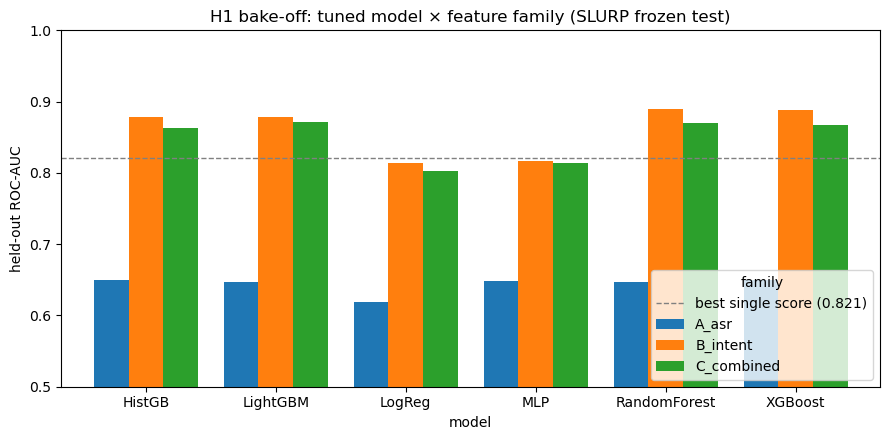

In [8]:
# --- figure: ROC-AUC by family × model ----------------------------------
piv = comp.pivot(index="model", columns="family", values="roc_auc")
ax = piv.plot(kind="bar", figsize=(9, 4.5), rot=0, width=0.8)
ax.set_ylabel("held-out ROC-AUC"); ax.set_ylim(0.5, 1.0)
ax.set_title("H1 bake-off: tuned model × feature family (SLURP frozen test)")
ax.axhline(base.roc_auc.max(), ls="--", c="grey", lw=1,
           label=f"best single score ({base.iloc[0].roc_auc:.3f})")
ax.legend(title="family", loc="lower right"); plt.tight_layout()
plt.savefig(OUT / "nb20_metric_bars.png", dpi=140); plt.show()

## Reading the result

- Compare **best-C vs best-B** in the H1 verdict cell above — that CI is the test.
- If A ≈ 0.5–0.6 while B is high, intent-native uncertainty is the near-sufficient
  statistic for downstream failure and richer ASR summaries add little — consistent
  with NB16–18. Appendix A (learned N-best/LM features) is the one remaining way to
  overturn this, and it needs a decode pass.
- The persisted `voxintel_r_best_risk.joblib` is the risk model used by NB21/22.